In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cftime

# Import modules
%reload_ext autoreload
%autoreload 2

In [3]:
# from src.netcdf import mat_to_xarray
import sys
sys.path.append('/Users/yugao/UOP/ORS-processing/src')

from util import convert_cftime_to_pandas_timestamp,  truncate_valid_hourly_data

In [4]:
netcdf_path = '/Users/yugao/UOP/ORS-processing/data/processed/stratus/' + 'stratus12_sbe16_1876.nc'
# Load the dataset
# Replace 'your_data.nc' with the path to your dataset file
ds = xr.open_dataset(netcdf_path )

/Users/yugao/miniforge3/envs/ors/lib/python3.12/site-packages/xarray/coding/times.py:995: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/yugao/miniforge3/envs/ors/lib/python3.12/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()


In [5]:
# Access the 'time_coverage_start' attribute
time_coverage_start_str = ds.attrs['time_coverage_start']

# Assuming the time_coverage_start is in a standard ISO format or similar,
# and you need to work with cftime objects
import cftime

# Parse the start date string into a cftime object
# The exact function to use depends on your calendar; assuming Gregorian here
time_coverage_start = cftime.num2date(0, units=f"days since {time_coverage_start_str}", calendar='gregorian')
# Define an end date, for instance, one year after the start
end_date = cftime.DatetimeGregorian(time_coverage_start.year + 1, time_coverage_start.month, time_coverage_start.day)

In [6]:
time_coverage_start_str = ds.attrs['time_coverage_start']

In [7]:
# Assuming temp is a NumPy array or a pandas Series containing temperature values
# Calculate the difference in temperature between consecutive time steps
temp = ds.temp.data
# Now temp_diff contains the temperature differences

In [8]:
regular_time_array = convert_cftime_to_pandas_timestamp(ds, start_date='2012-05-14T00:59:59Z')


In [14]:
truncated_ds = truncate_valid_hourly_data(ds)

In [15]:
truncated_ds

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 31158)
Coordinates:
  * time     (time) object 249kB 3912-05-30 09:29:59.999993 ... 3914-03-10 12...
Data variables:
    temp     (time) float64 249kB 1.821 1.821 1.82 1.82 ... 1.768 3.788 17.68
    cond     (time) float64 249kB 3.218 3.218 3.218 3.218 ... 3.191 3.247 4.583
    sal      (time) float64 249kB 34.69 34.69 34.69 34.69 ... 34.43 33.05 33.76
    sal_sbe  (time) float64 249kB 34.69 34.69 34.69 34.69 ... 34.43 33.05 33.76
Attributes: (12/25)
    depth:                                  4502
    latitude:                               -19.93844
    longitude:                              -85.29266333333334
    site:                                   Stratus
    deployment:                             12
    experiment:                             Stratus Ocean Reference Station
    ...                                     ...
    water_depth_from_mooring_diagram:       4450
    water_depth_from_ship_uncorrected:      4562.2
    water_depth_from_ship_corrected:        4538.97
    instrument_depth_from_mooring_diagram:  4411
    instrument_depth_from_mooring_log:      4499.97
    instrument_height_above_bottom:         39

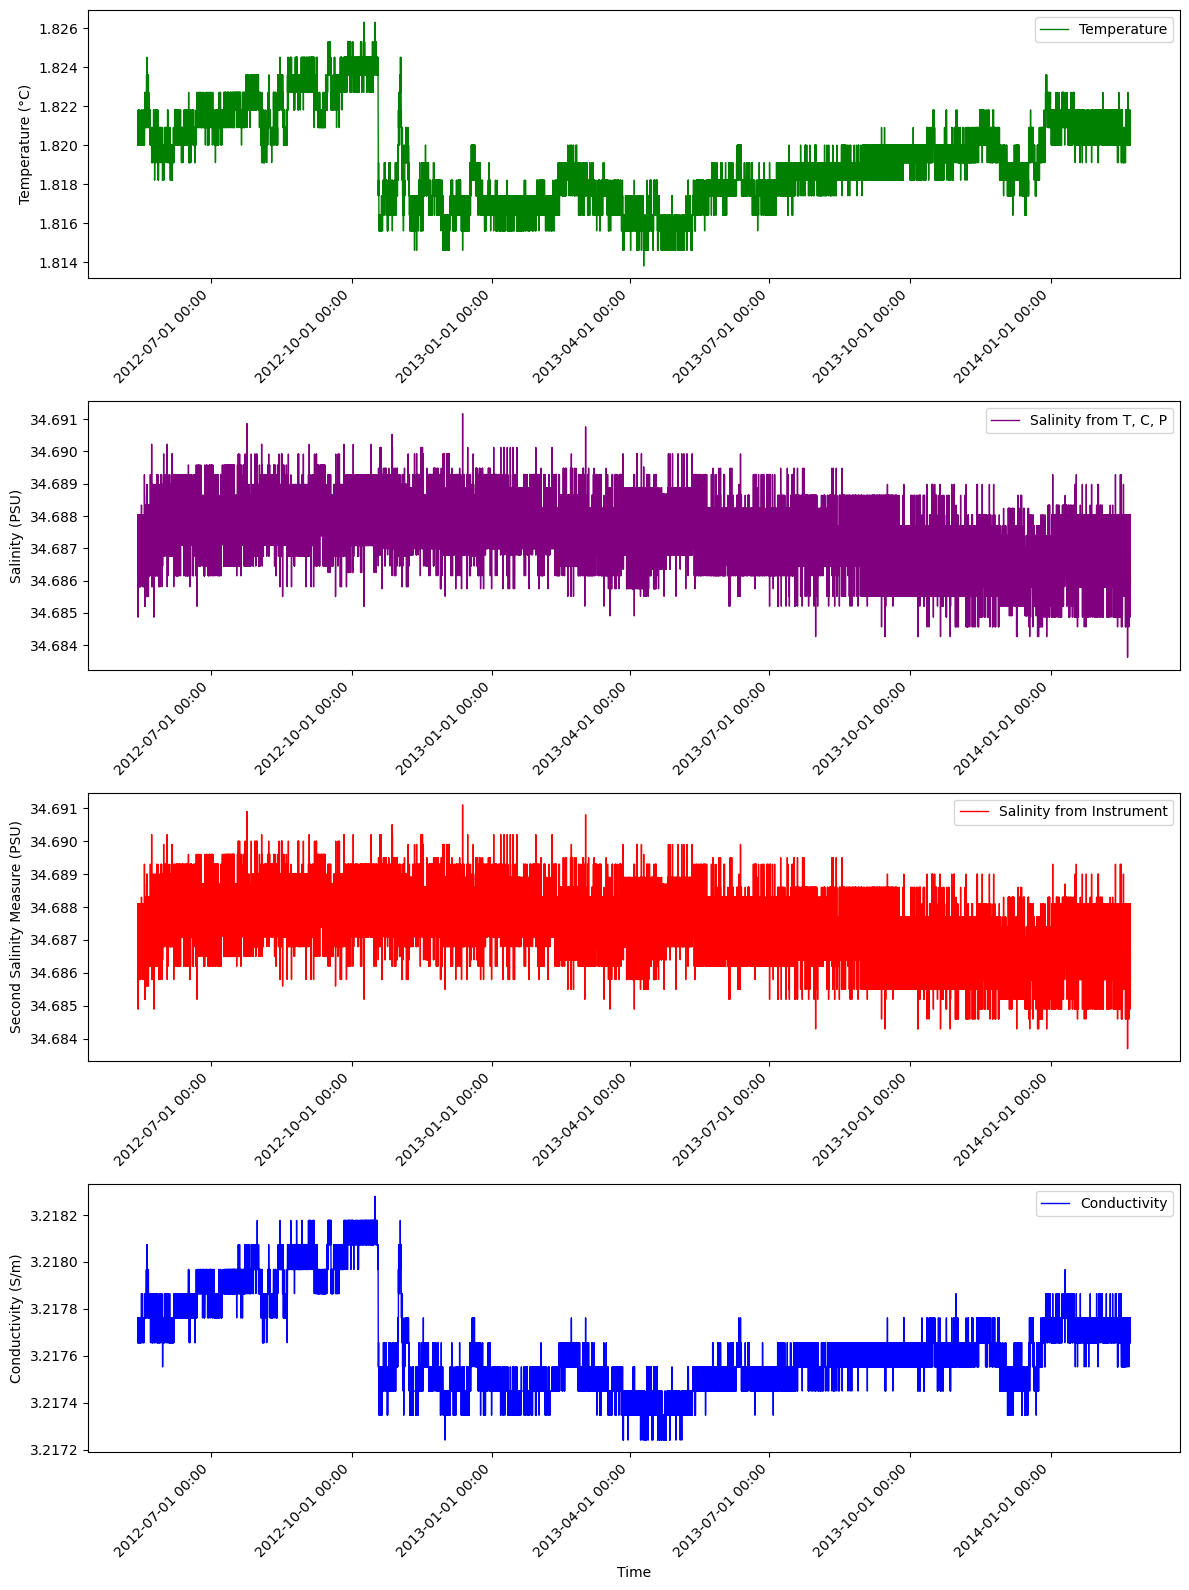

<Figure size 640x480 with 0 Axes>

In [16]:

# Converting cftime to Pandas Timestamp
regular_time_array = convert_cftime_to_pandas_timestamp(truncated_ds, start_date='2012-05-14T00:59:59Z')

# Creating subplots
fig, axs = plt.subplots(4, 1, figsize=(12, 16))

# Variables to plot
variables = ['temp', 'sal', 'sal_sbe', 'cond']
colors = ['green', 'purple', 'red', 'blue']
labels = ['Temperature', 'Salinity from T, C, P', 'Salinity from Instrument', 'Conductivity']
y_labels = ['Temperature (°C)', 'Salinity (PSU)', 'Second Salinity Measure (PSU)', 'Conductivity (S/m)']

# Plot each variable with regular_time_array as x-axis
for ax, var, color, label, y_label in zip(axs, variables, colors, labels, y_labels):
    ax.plot(regular_time_array[:-3], truncated_ds[var].values[:-3], color=color, linewidth=1, label=label)
    ax.set_ylabel(y_label)
    ax.legend()

# Set the xlabel for the last subplot
axs[-1].set_xlabel('Time')

# Customize the x-axis date formatting for better readability
for ax in axs:
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()
plt.savefig(f'../../img/{netcdf_path[-32:-2]}.png')  # Adjust path as needed


In [17]:
ds.sal_sbe - ds.sal

<xarray.DataArray (time: 31872)> Size: 255kB
array([-8.69874659e-03, -8.65180942e-03, -8.59796095e-03, ...,
       -4.43290489e-05,  4.42579229e-05,  4.42579229e-05])
Coordinates:
  * time     (time) object 255kB 3912-05-16 00:59:59.999997 ... 3914-03-11 00...

In [19]:
print(truncated_ds)

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 31158)
Coordinates:
  * time     (time) object 249kB 3912-05-30 09:29:59.999993 ... 3914-03-10 12...
Data variables:
    temp     (time) float64 249kB 1.821 1.821 1.82 1.82 ... 1.768 3.788 17.68
    cond     (time) float64 249kB 3.218 3.218 3.218 3.218 ... 3.191 3.247 4.583
    sal      (time) float64 249kB 34.69 34.69 34.69 34.69 ... 34.43 33.05 33.76
    sal_sbe  (time) float64 249kB 34.69 34.69 34.69 34.69 ... 34.43 33.05 33.76
Attributes: (12/25)
    depth:                                  4502
    latitude:                               -19.93844
    longitude:                              -85.29266333333334
    site:                                   Stratus
    deployment:                             12
    experiment:                             Stratus Ocean Reference Station
    ...                                     ...
    water_depth_from_mooring_diagram:       4450
    water_depth_from_ship_uncorrected:      4562.2
    water